# Rice Field Classification Project
**Author:** Purinut Chairungrueang

## Objectives
1.  **Develop Model:** To build a Machine Learning model for rice field classification.
2.  **Analyze Patterns:** To study the spectral signature and growth cycle of rice crops using temporal NDVI data.
3.  **Application:** To demonstrate the potential of geospatial data in agricultural surveying.

## 1. Project Overview
This project aims to classify Rice Field areas in Mueang District, Suphan Buri Province. By integrating Remote Sensing technology with Machine Learning (Random Forest), we analyze the annual NDVI time-series data derived from Sentinel-2 satellite imagery (via Google Earth Engine).

**Workflow:**
1.  **Spatial Data Preprocessing:** Clean and process Landuse Shapefile (from LDD) to correct coordinates and select sample points.
2.  **Feature Engineering (GEE):** Extract temporal NDVI signatures from Sentinel-2 satellite imagery using Google Earth Engine.
3.  **Machine Learning:** Train a Random Forest model to classify Rice Fields vs. Non-Rice areas.

In [ ]:
# Import Libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Machine Learning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Import Geospatial & GEE
import ee
import geemap

# Initialize GEE (if running locally)
# ee.Authenticate()
# ee.Initialize()

## 2. Spatial Data Preprocessing
We start with the Land Use Shapefile (2021) of Suphan Buri.
* **Step 1:** Load raw shapefile.
* **Step 2:** Coordinate Reference System (CRS) Transformation. GEE requires **EPSG:4326 (WGS84)**, so we convert the local projection (UTM) to Lat/Lon.
* **Step 3:** Class Labeling (Rice=1, Others=0).

In [ ]:
# Load the Shapefile
# NOTE: Ensure the file path is correct relative to your notebook location
gdf = gpd.read_file('Landuse_Suphan_2021.shp')

In [ ]:
# Create a binary target 'Label': 1 for Rice, 0 for Non-Rice
rice_cate = ['Active paddy field', 'Active field+Corn', 'Active paddy field+Mungbean']
gdf['Label'] = gdf['LU_DES_EN'].apply(lambda x: 1 if x in rice_cate else 0)

# Check Class Distribution
print("Class Distribution:\n", gdf['Label'].value_counts())

In [ ]:
# Check Coordinate Reference System (CRS)
gdf.crs

In [ ]:
# Coordinate Reference System (CRS) Transformation
# GEE requires WGS84 (EPSG:4326). If the data is in UTM, convert it.
gdf_wgs84 = gdf.to_crs(epsg = 4326)

In [ ]:
# Geographic Distribution Check: Mapping a sample of Rice vs. Non-Rice labels
ax = gdf_wgs84.sample(500).plot(column='Label', cmap='RdYlGn', legend=True, figsize=(8, 8))
plt.title('Check Label: Green = Rice (1), Red = Non-Rice (0)')
plt.show()

In [ ]:
# -- Sampling for Rice Fields (Class 1) --
# Sample 3 points per polygon to increase data density for rice
rice_fields = gdf_wgs84[gdf_wgs84['Label'] == 1]
rice_points_rd = rice_fields.sample_points(size = 3)
rice_points_gdf = rice_points_rd.explode(index_parts = False).to_frame(name = 'Geometry')
rice_points_gdf['Class'] = 1

In [ ]:
# -- Sampling for Non-Rice Areas (Class 0) --
# Randomly select 1500 polygons and sample 1 point per polygon
non_rice_fields = gdf_wgs84[gdf_wgs84['Label'] == 0]
non_rice_points_rd = non_rice_fields.sample(n= 1500, replace = True)
non_rice_points_gdf = non_rice_points_rd.sample_points(size = 1)
non_rice_points_gdf = non_rice_points_gdf.explode(index_parts = False).to_frame(name = 'Geometry')
non_rice_points_gdf['Class'] = 0

In [ ]:
# Combine & Extract Coordinates
df = pd.concat([rice_points_gdf, non_rice_points_gdf])
df['lat'] = df.geometry.x
df['lon'] = df.geometry.y
df = df.drop(columns = 'Geometry').reset_index(drop = True)

## 3. Feature Engineering via Google Earth Engine (GEE)
We upload the processed coordinates to GEE to extract satellite data.
* **Satellite:** Sentinel-2 (Level-2A)
* **Features:** Monthly NDVI (Jan-Dec) + Statistical Aggregates (Min, Max, Mean, StdDev).
* **Extraction Strategy:**
    1. **Direct Extraction:** We use `reduceRegions()` to extract pixel values directly into a Pandas DataFrame (`df_final`) for immediate model training.
    2. **Asset Export:** A background task (`Export.image.toAsset`) is also initiated to save the processed image for future spatial mapping.

In [ ]:
# Initialize GEE
try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()

In [ ]:
# Load District Boundary (for precise clipping)
gdf_district = gpd.read_file('MuangSuphan/muang_suphan.shp')
if gdf_district.crs != "EPSG:4326":
    gdf_district = gdf_district.to_crs("EPSG:4326")

ee_district = geemap.gdf_to_ee(gdf_district)
region_precise = ee_district.geometry()

In [ ]:
# Convert DataFrame points to GEE FeatureCollection
points = ee.FeatureCollection([
    ee.Feature(
        ee.Geometry.Point([row['lat'], row['lon']]), 
        {'class': row['Class']}
    ) for i, row in df.iterrows()
])

In [ ]:
start_date = '2021-01-01'
end_date = '2021-12-31'

# Retrieve Sentinel-2 Imagery
# Filter: Suphan Buri District, Year 2021, Cloud Cover < 40%
s2_col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40)))

In [ ]:
# Compute Monthly NDVI (12 Months)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_list = []

for i, month in enumerate(range(1, 13)):
    # Calculate Median to minimize cloud contamination
    month_img = s2_col.filter(ee.Filter.calendarRange(month, month, 'month')).median()
    band_name = f'NDVI_{month:02d}_{month_names[i]}'

    # Calculate NDVI: (NIR - Red) / (NIR + Red)
    ndvi = month_img.normalizedDifference(['B8', 'B4']).rename(band_name)
    monthly_list.append(ndvi)

In [ ]:
# Stack 12 monthly images and add 4 statistical bands (Total 16 bands)
annual_stack = ee.Image.cat(monthly_list)

stats_img = ee.Image.cat([
    annual_stack.reduce(ee.Reducer.max()).rename('NDVI_Max'),
    annual_stack.reduce(ee.Reducer.min()).rename('NDVI_Min'),
    annual_stack.reduce(ee.Reducer.mean()).rename('NDVI_Mean'),
    annual_stack.reduce(ee.Reducer.stdDev()).rename('NDVI_StdDev')
])

In [ ]:
final_img = annual_stack.addBands(stats_img)

# Define Export Task
my_project = 'your-gee-project-name' # Update with your actual GEE project name
full_asset_path = f'projects/{my_project}/assets/Suphan_NDVI_2021'

task = ee.batch.Export.image.toAsset(
    image = final_img,
    description = 'Export_Suphan_NDVI',
    assetId = full_asset_path,
    region = region_precise,
    scale = 10,
    maxPixels = 1e13,
    shardSize = 256
)
task.start()

In [ ]:
# Download Asset
asset_id = 'projects/{my_project}/assets/Suphan_NDVI_2021'
baked_image = ee.Image(asset_id)

In [ ]:
# Export Table to Google Drive (Generates the CSV for Model Training)
# We sample the values from 'final_img' directly at our sample points.
sampled_fc = baked_image.sampleRegions(
    collection=points,
    properties=['class'],
    scale=10,
    tileScale=16
)

task = ee.batch.Export.table.toDrive(
    collection=sampled_fc,
    description='Suphan_NDVI_Dataset',
    fileFormat='CSV'
)
task.start()

## 4. Exploratory Data Analysis (EDA)
We analyze the Temporal NDVI Signature (Phenological Cycle) to distinguish rice fields from other land cover types.
* **Objective:** Compare the average monthly NDVI values between **Rice Fields (Class 1)** and **Others (Class 0)**.
* **Expected Pattern:** Rice crops should show a distinct growth curve (low at sowing, high at peak vegetative stage, low at harvest).

In [6]:
df = pd.read_csv('Suphan_NDVI_Dataset.csv')

In [7]:
df.head()

,system:index,NDVI_01_Jan,NDVI_02_Feb,NDVI_03_Mar,NDVI_04_Apr,NDVI_05_May,NDVI_06_Jun,NDVI_07_Jul,NDVI_08_Aug,NDVI_09_Sep,NDVI_10_Oct,NDVI_11_Nov,NDVI_12_Dec,NDVI_Max,NDVI_Mean,NDVI_Min,NDVI_StdDev,class,.geo
0,0_0,0.548387,0.711209,0.604305,0.220822,0.335134,0.738380,0.739364,0.401268,-0.098417,0.184592,0.019531,-0.153693,0.739364,0.354240,-0.153693,0.309249,1,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1_0,0.368352,0.371167,0.341265,0.224664,0.291972,0.438609,0.452636,0.470106,0.391274,0.128882,0.089322,0.042618,0.470106,0.300905,0.042618,0.140493,1,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,2_0,0.409121,0.446581,0.432489,0.339243,0.335953,0.501475,0.572341,0.526817,0.464056,0.189983,0.216260,0.064516,0.572341,0.374903,0.064516,0.145529,1,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,3_0,0.389335,0.477647,0.494491,0.411852,0.589181,0.667656,0.746455,0.587924,0.809391,0.414164,0.691568,0.536373,0.809391,0.568003,0.389335,0.132507,1,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,4_0,0.277872,0.738610,0.607913,0.311961,0.240157,0.670968,0.742965,0.383715,0.045177,-0.311909,0.249866,-0.220527,0.742965,0.311397,-0.311909,0.334604,1,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [8]:
df = df.drop(columns = ['system:index', '.geo'])

In [9]:
df.isnull().sum()

NDVI_01_Jan    0
NDVI_02_Feb    0
NDVI_03_Mar    0
NDVI_04_Apr    0
NDVI_05_May    0
NDVI_06_Jun    0
NDVI_07_Jul    0
NDVI_08_Aug    0
NDVI_09_Sep    0
NDVI_10_Oct    0
NDVI_11_Nov    0
NDVI_12_Dec    0
NDVI_Max       0
NDVI_Mean      0
NDVI_Min       0
NDVI_StdDev    0
class          0
dtype: int64

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3831 entries, 0 to 3830
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NDVI_01_Jan  3831 non-null   float64
 1   NDVI_02_Feb  3831 non-null   float64
 2   NDVI_03_Mar  3831 non-null   float64
 3   NDVI_04_Apr  3831 non-null   float64
 4   NDVI_05_May  3831 non-null   float64
 5   NDVI_06_Jun  3831 non-null   float64
 6   NDVI_07_Jul  3831 non-null   float64
 7   NDVI_08_Aug  3831 non-null   float64
 8   NDVI_09_Sep  3831 non-null   float64
 9   NDVI_10_Oct  3831 non-null   float64
 10  NDVI_11_Nov  3831 non-null   float64
 11  NDVI_12_Dec  3831 non-null   float64
 12  NDVI_Max     3831 non-null   float64
 13  NDVI_Mean    3831 non-null   float64
 14  NDVI_Min     3831 non-null   float64
 15  NDVI_StdDev  3831 non-null   float64
 16  class        3831 non-null   int64  
dtypes: float64(16), int64(1)
memory usage: 508.9 KB


In [11]:
df.describe()

,NDVI_01_Jan,NDVI_02_Feb,NDVI_03_Mar,NDVI_04_Apr,NDVI_05_May,NDVI_06_Jun,NDVI_07_Jul,NDVI_08_Aug,NDVI_09_Sep,NDVI_10_Oct,NDVI_11_Nov,NDVI_12_Dec,NDVI_Max,NDVI_Mean,NDVI_Min,NDVI_StdDev,class
count,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000,3831.000000
mean,0.436056,0.440268,0.347336,0.352113,0.458091,0.495545,0.547072,0.437293,0.397586,0.481288,0.453511,0.421966,0.716629,0.439010,0.151033,0.174326,0.608457
std,0.180642,0.200984,0.136997,0.174721,0.213794,0.218783,0.234267,0.211238,0.261132,0.355681,0.277965,0.238715,0.157013,0.137469,0.223148,0.085646,0.488159
min,-0.260717,-0.317042,-0.186202,-0.402799,-0.421687,-0.281414,-0.412625,-0.991379,-0.911504,-0.990050,-0.489289,-0.569592,-0.057851,-0.371634,-0.991379,0.021259,0.000000
25%,0.289486,0.280287,0.243696,0.214908,0.287832,0.321094,0.370302,0.259775,0.201353,0.298077,0.264460,0.258455,0.662088,0.361697,0.071983,0.107890,0.000000
50%,0.418274,0.408043,0.325955,0.334689,0.469772,0.494854,0.591146,0.451685,0.392510,0.593418,0.510467,0.438441,0.763467,0.444311,0.174002,0.161943,1.000000
75%,0.577910,0.598221,0.444910,0.483329,0.627930,0.684501,0.752933,0.611168,0.611560,0.750782,0.684828,0.611564,0.821539,0.528900,0.285973,0.227220,1.000000
max,0.837194,0.889390,0.798547,0.811317,0.896495,0.931812,0.912113,0.903037,0.934397,0.929947,0.895931,0.873965,0.934397,0.793453,0.671360,0.589882,1.000000


In [12]:
ndvi_list = ['NDVI_01_Jan', 'NDVI_02_Feb', 'NDVI_03_Mar', 'NDVI_04_Apr', 'NDVI_05_May', 'NDVI_06_Jun',
             'NDVI_07_Jul', 'NDVI_08_Aug', 'NDVI_09_Sep', 'NDVI_10_Oct', 'NDVI_11_Nov', 'NDVI_12_Dec']

In [ ]:
df_group = df.groupby(['class'])[ndvi_list].mean()

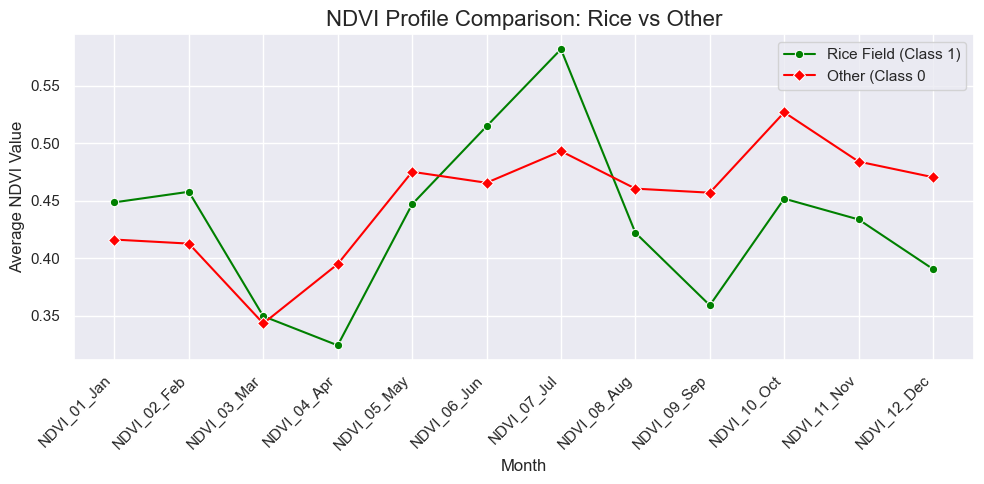

In [14]:
plt.figure(figsize= (10, 5))
sns.set_theme()
sns.lineplot(x = ndvi_list, y = df_group.loc[1], 
             label = 'Rice Field (Class 1)',
             color = 'green',
             marker = 'o')
sns.lineplot(x = ndvi_list, y = df_group.loc[0],
             label = 'Other (Class 0',
             color = 'red',
             marker = 'D')
plt.xlabel('Month')
plt.ylabel('Average NDVI Value')
plt.xticks(rotation = 45, horizontalalignment = 'right')
plt.title('NDVI Profile Comparison: Rice vs Other', fontsize = 16)
plt.tight_layout()
plt.show()

## 5. Model Training (Random Forest)
We split the dataset into training and testing sets to evaluate the model's performance on unseen data.
* **Algorithm:** Random Forest Classifier (Robust against overfitting).
* **Features (X):** 16 Variables (12 Monthly NDVI + 4 Statistical metrics).
* **Target (y):** Class (0 = Other, 1 = Rice).
* **Splitting Strategy:** 70% Training / 30% Testing (with Stratified Sampling to maintain class balance).

In [ ]:
# features (X): NDVI 12 month + 4 descrip statistics
features = ndvi_list + ['NDVI_Max', 'NDVI_Min', 'NDVI_Mean', 'NDVI_StdDev']
X = df[features]

# labels (y): `class` column
y = df['class']

# split: Train 70% Test 30%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, stratify = y
)

In [ ]:
# train model
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Accuracy: 79.57%
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74       450
           1       0.84      0.82      0.83       700

    accuracy                           0.80      1150
   macro avg       0.79      0.79      0.79      1150
weighted avg       0.80      0.80      0.80      1150



C:\Users\MSI\AppData\Local\Temp\ipykernel_25092\402527569.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='magma')


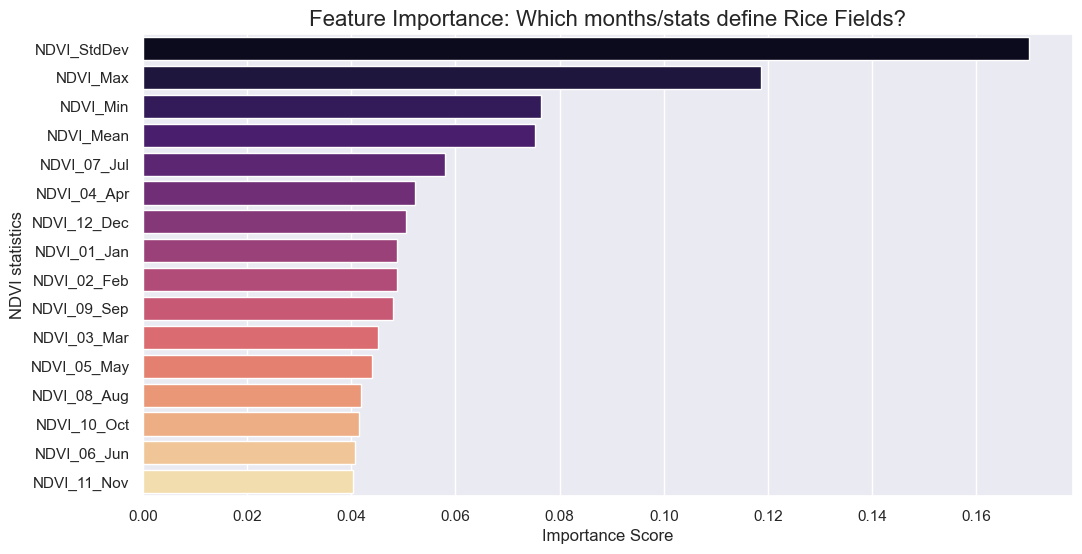

In [ ]:
y_pred = rf_model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print('Classification Report:')
print(f'{classification_report(y_test, y_pred)}')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index = X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.set_theme()
sns.barplot(x=importances, y=importances.index, palette='magma')
plt.title('Feature Importance: Which months/stats define Rice Fields?', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('NDVI statistics')
plt.show()

<Figure size 800x600 with 0 Axes>

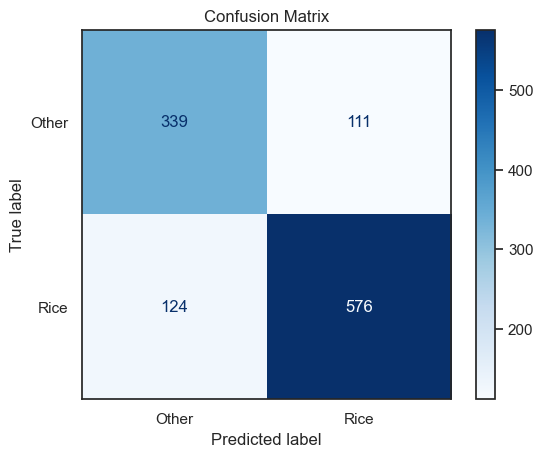

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (8, 6))
sns.set_theme(style = 'white')
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['Other', 'Rice'])
disp.plot(cmap = 'Blues')
plt.title('Confusion Matrix')
plt.show()

## 6. Model Optimization (Hyperparameter Tuning)
To improve model performance and prevent overfitting, we perform Hyperparameter Tuning using `RandomizedSearchCV`.
* **Technique:** Randomized Search (Faster than Grid Search for high-dimensional parameter spaces).
* **Parameters Tuned:** Number of trees (`n_estimators`), Tree depth (`max_depth`), Split criteria (`min_samples_split`).

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300], 
    'max_depth': [10, 20, 30, None], 
    'min_samples_split': [2, 5, 10], 
    'bootstrap': [True, False]       
}

In [ ]:
rf_random = RandomizedSearchCV(
    estimator=rf_model, 
    param_distributions=param_dist, 
    n_iter=10, cv=3, random_state=42, n_jobs=-1
)

In [49]:
# Tuning
rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, None],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42)

In [50]:
# result
best_model = rf_random.best_estimator_
print(f"Best parameters: {rf_random.best_params_}")
print(f"New Accuracy: {best_model.score(X_test, y_test) * 100:.2f}%")

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 20, 'bootstrap': True}
New Accuracy: 80.43%


## 7. Conclusion & Final Results

### Model Performance
The Random Forest Classifier successfully identified rice fields in Suphan Buri with high precision after hyperparameter optimization.
* **Final Accuracy:** 80.43%
* **Optimization:** The best performance was achieved with `n_estimators=200`, `max_depth=20`, and `min_samples_split=2`.

### Key Domain Insights
1.  **Phenological Signature:** The analysis confirms that rice fields exhibit a distinct NDVI growth cycle, peaking significantly during the growing season (**July - October**). This temporal pattern is the most critical feature for classification.
2.  **Feature Importance:** Monthly NDVI values (specifically during the wet season) proved to be stronger predictors than simple annual statistics (Mean/Max), emphasizing the importance of multi-temporal analysis in remote sensing.

### Future Recommendations
* **Integration with Radar Data:** Incorporating **Sentinel-1 (SAR)** data could further improve accuracy by overcoming cloud cover limitations during the rainy season.
* **Scalability:** This workflow can be scaled to monitor rice production across the entire Central Plain of Thailand, serving as an automated tool for agricultural zoning and yield estimation.